# Agentic RAG

### An agent that can answer user questions by consulting a collection of documents. 
### Instead of relying solely on the model’s internal knowledge, the agent will ground its responses in an external source of truth.


We are creating a LangGraph Workflow that includes:

* A document loading and vectorization process for a knowledge base.
* An Agent Node capable of:
    * Retrieving relevant knowledge.
    * Augmenting responses with contextual documents.
    * Generating accurate answers.
    * Conditional routing to control query resolution.
    * Optimization techniques such as text chunking and embedding search.

In [4]:
from typing import List
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_community.document_loaders import PyPDFLoader
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import MessagesState
from IPython.display import Image, display

from dotenv import load_dotenv
load_dotenv("/Users/oasis/Udacity AI Masters/Agentic/Code/.env")

True

In [7]:
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.0,
)

embeddings_fn = OpenAIEmbeddings(
    model="text-embedding-3-large"
)

In [9]:
vector_store = Chroma(
    collection_name="agnetic_ai",
    embedding_function=embeddings_fn
)


In [ ]:
file_path = "compact-guide-to-large-language-models.pdf"
loader = PyPDFLoader(file_path)

In [11]:
pages = []
async for page in loader.alazy_load():
    pages.append(page)

In [12]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
all_splits = text_splitter.split_documents(pages)
_ = vector_store.add_documents(documents=all_splits)


In [13]:
# Define State Schema

class State(MessagesState):
    question: str
    documents: List[Document]
    #search_required: str = "NO"
    answer: str


#  RAG Nodes
def retrieve(state: State):
    question = state["question"]
    # Using the similarity_search() method
    retrieved_docs = vector_store.similarity_search(question)
    return {"documents": retrieved_docs}




def augment(state: State):
    question = state["question"]
    documents = state["documents"]
    docs_content = "\n\n".join(doc.page_content for doc in documents)

    template = ChatPromptTemplate([
        ("system", "You are an assistant for question-answering tasks."),
        ("human", "Use the following pieces of retrieved context to answer the question. "
                "If you don't know the answer, just say that you don't know. " 
                "Use three sentences maximum and keep the answer concise. "
                "\n# Question: \n-> {question} "
                "\n# Context: \n-> {context} "
                "\n# Answer: "),
    ])

    messages = template.invoke(
        {"context": docs_content, "question": question}
    ).to_messages()

    return {"messages": messages}


def generate(state: State):
    ai_message = llm.invoke(state["messages"])
    return {"answer": ai_message.content, "messages": ai_message}


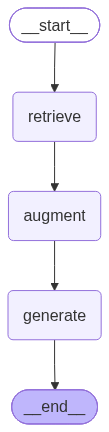

In [14]:
# Build the LangGraph Workflow

workflow = StateGraph(State)
workflow = StateGraph(State)

workflow.add_node("retrieve", retrieve)
workflow.add_node("augment", augment)
workflow.add_node("generate", generate)

workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "augment")
workflow.add_edge("augment", "generate")
workflow.add_edge("generate", END)



graph = workflow.compile()

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)




In [15]:
# Invoke the Agent with a Query

output = graph.invoke(
    {"question": "What are Open source models?"}
)

output["answer"]

for message in output["messages"]:
    message.pretty_print()

================================ System Message ================================

You are an assistant for question-answering tasks.
================================ Human Message =================================

Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise. 
# Question: 
-> What are Open source models? 
# Context: 
-> very limited use, so cost becomes a factor in applying these at scale.
In summary: Proprietary services are great to use if you have very complex tasks, 
are okay with sharing your data with a third party, and are prepared to incur 
costs if operating at any significant scale.  
Open source models
The other avenue for language models is to go to the open source community, 
where there has been similarly explosive growth over the past few years. 
Communities like Hugging Face  gather hundreds of thousands of models 
from contributo